In [3]:
pip install --force-reinstall geopandas

  Using cached geopandas-1.1.1-py3-none-any.whl.metadata (2.3 kB)
  Using cached python_dateutil-2.9.0.post0-py2.py3-none-any.whl.metadata (8.4 kB)
  Using cached pytz-2025.2-py2.py3-none-any.whl.metadata (22 kB)
  Using cached tzdata-2025.2-py2.py3-none-any.whl.metadata (1.4 kB)
  Using cached six-1.17.0-py2.py3-none-any.whl.metadata (1.7 kB)
Using cached geopandas-1.1.1-py3-none-any.whl (338 kB)
   ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
    --------------------------------------- 0.3/12.8 MB ? eta -:--:--
    -----------------------------------

  You can safely remove it manually.
  You can safely remove it manually.
  You can safely remove it manually.
  You can safely remove it manually.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
catboost 1.2.7 requires numpy<2.0,>=1.16.0, but you have numpy 2.3.2 which is incompatible.
opencv-python 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 2.3.2 which is incompatible.


In [9]:
import geopandas as gpd
from pathlib import Path

# full absolute path
shp_path = Path(r"C:\Users\dedee\Downloads\epidemic-project\data_raw\shapefiles\india_states.shp")
print(shp_path.exists())   # should print True if the file is found

gdf = gpd.read_file(shp_path)
print(gdf.head())


True
               ST_NM                                           geometry
0  Arunachal Pradesh  POLYGON ((96.08866 29.45997, 96.09428 29.45477...
1              Assam  POLYGON ((95.97166 27.96254, 95.97174 27.96227...
2         Chandigarh  POLYGON ((76.77175 30.79498, 76.77231 30.7942,...
3          Karnataka  POLYGON ((77.32647 18.45884, 77.32648 18.45803...
4            Manipur  POLYGON ((94.57315 25.69156, 94.57522 25.69094...


In [20]:
from pathlib import Path
import pandas as pd

PANEL_CSV = Path(r"C:\Users\dedee\Downloads\epidemic-project\data_curated\panel_state_daily.csv")
print(PANEL_CSV.exists())  # Should print True

panel = pd.read_csv(PANEL_CSV)


True


In [21]:
# src/adjacency.py
import geopandas as gpd
import pandas as pd
from pathlib import Path
import sys

# --- Project Root ---
try:
    PROJECT_ROOT = Path(__file__).resolve().parents[1]
except NameError:
    # running in Jupyter
    PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "src" else Path.cwd()

# --- Paths ---
SHAPEFILE = PROJECT_ROOT / "data_raw" / "shapefiles" / "india_states.shp"
PANEL_CSV = PROJECT_ROOT / "data_curated" / "panel_state_daily.csv"
OUT_DIR = PROJECT_ROOT / "data_curated"
OUT_DIR.mkdir(parents=True, exist_ok=True)

# --- Check files ---
if not SHAPEFILE.exists():
    sys.exit(f"Shapefile not found: {SHAPEFILE}")
if not PANEL_CSV.exists():
    sys.exit(f"Panel CSV not found: {PANEL_CSV}. Run etl.py first!")

# --- Load shapefile ---
gdf = gpd.read_file(SHAPEFILE)

# Adjust column name from shapefile
if 'ST_NM' in gdf.columns:
    gdf['state'] = gdf['ST_NM'].str.strip()
elif 'st_name' in gdf.columns:
    gdf['state'] = gdf['st_name'].str.strip()
else:
    sys.exit("No recognizable state name column in shapefile")

# --- Load panel CSV to get valid states ---
states = pd.read_csv(PANEL_CSV)['state'].unique()
gdf = gdf[gdf['state'].isin(states)]

# --- Compute adjacency ---
gdf = gdf.reset_index(drop=True)
gdf['geometry'] = gdf['geometry'].buffer(0)  # fix invalid geometry
neighbors = {}
for i, row in gdf.iterrows():
    nbs = gdf[gdf.geometry.touches(row.geometry)]['state'].tolist()
    neighbors[row['state']] = nbs

# --- Convert to adjacency DataFrame ---
adj_df = pd.DataFrame(0, index=gdf['state'], columns=gdf['state'])
for s, nbs in neighbors.items():
    for nb in nbs:
        adj_df.loc[s, nb] = 1

# --- Save ---
adj_df.to_csv(OUT_DIR / "state_adjacency.csv")
print("Saved adjacency to", OUT_DIR / "state_adjacency.csv")


Saved adjacency to C:\Users\dedee\Downloads\epidemic-project\data_curated\state_adjacency.csv


In [23]:
adj_df.head()


state,Arunachal Pradesh,Assam,Chandigarh,Karnataka,Manipur,Meghalaya,Mizoram,Nagaland,Punjab,Rajasthan,...,Haryana,Himachal Pradesh,Jharkhand,Tamil Nadu,Uttar Pradesh,West Bengal,Andhra Pradesh,Puducherry,Maharashtra,Ladakh
state,,,,,,,,,,,,,,,,,,,,,
Arunachal Pradesh,0,1,0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
Assam,1,0,0,0,1,1,1,1,0,0,...,0,0,0,0,0,1,0,0,0,0
Chandigarh,0,0,0,0,0,0,0,0,1,0,...,1,0,0,0,0,0,0,0,0,0
Karnataka,0,0,0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,1,0,1,0
Manipur,0,1,0,0,0,0,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0


In [26]:
pip install networkx matplotlib


   ---------------------------------------- 0.0/2.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.0 MB ? eta -:--:--
   ----- ---------------------------------- 0.3/2.0 MB ? eta -:--:--
   ----- ---------------------------------- 0.3/2.0 MB ? eta -:--:--
   ---------- ----------------------------- 0.5/2.0 MB 799.2 kB/s eta 0:00:02
   --------------- ------------------------ 0.8/2.0 MB 745.8 kB/s eta 0:00:02
   --------------- ------------------------ 0.8/2.0 MB 745.8 kB/s eta 0:00:02
   --------------- ------------------------ 0.8/2.0 MB 745.8 kB/s eta 0:00:02
   -------------------- ------------------- 1.0/2.0 MB 637.3 kB/s eta 0:00:02
   -------------------- ------------------- 1.0/2.0 MB 637.3 kB/s eta 0:00:02
   -------------------- ------------------- 1.0/2.0 MB 637.3 kB/s eta 0:00:02
   -------------------- ------------------- 1.0/2.0 MB 637.3 kB/s eta 0:00:02
   -------------------- ------------------- 1.0/2.0 MB 637.3 kB/s eta 0:00:02
   -------------------

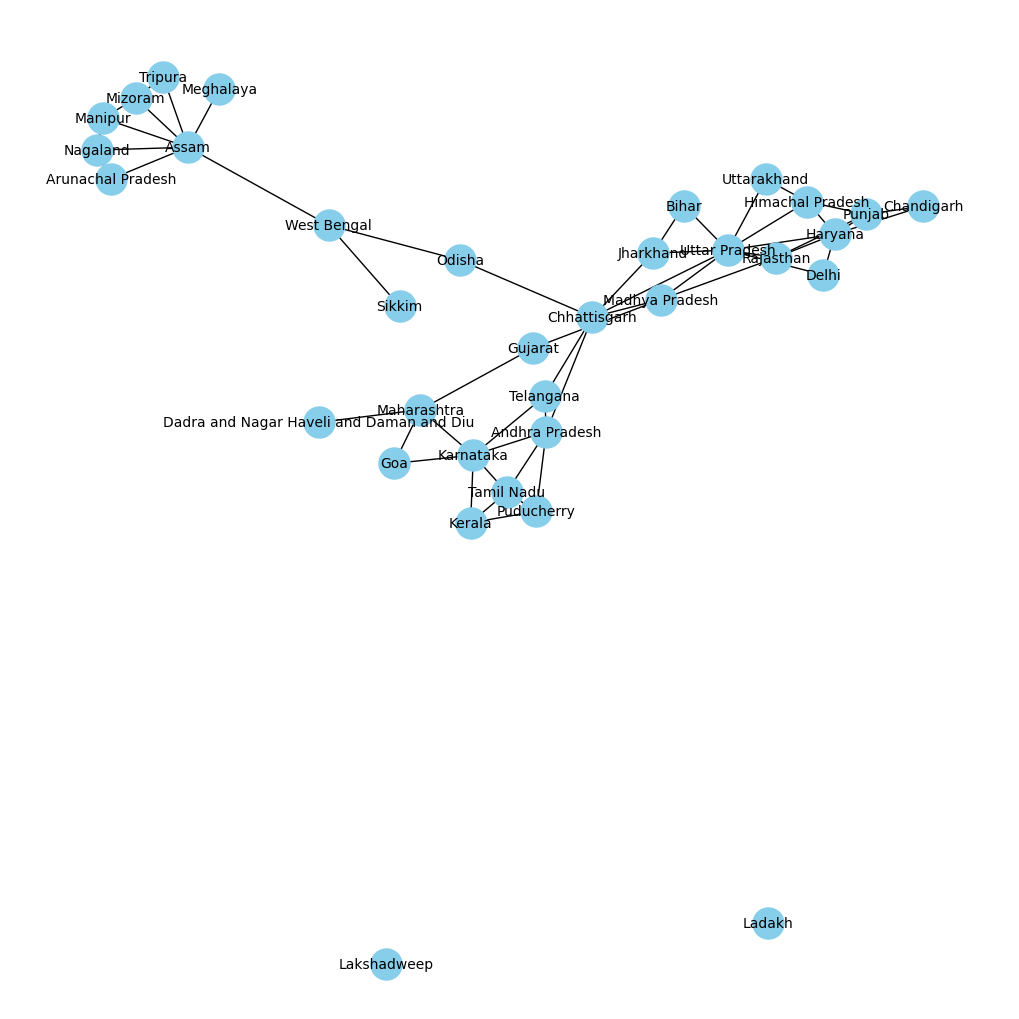

In [27]:
import networkx as nx
import matplotlib.pyplot as plt

G = nx.from_pandas_adjacency(adj_df)
plt.figure(figsize=(10,10))
nx.draw(G, with_labels=True, node_size=500, node_color='skyblue', font_size=10)
plt.show()
